# SO3.2-01 — Inventário e validação das entradas do SO3.1

## Objetivo

Inventariar e avaliar a consistência técnica dos produtos de ameaça provenientes do SO3.1 que serão utilizados no cálculo da exposição populacional do SO3.2.

Esta etapa verifica:

- completude temporal;
- conformidade da nomenclatura;
- propriedades técnicas dos GeoTIFFs;
- domínio e distribuição das classes de seca;
- consistência da grade entre os anos;
- estabilidade temporal da máscara de dados;
- distribuição temporal e espacial de eventuais valores ausentes.

Esta etapa **não recalcula o SPEI-12, não reclassifica os dados de seca e não modifica os produtos do SO3.1**.

## Dados de entrada

Os produtos do SO3.1 são GeoTIFFs anuais do SPEI-12 de dezembro, previamente classificados.

- **Período esperado:** 2000–2023
- **Número esperado de arquivos:** 24
- **Padrão de nomenclatura:** `spei12_dezembro_YYYY_brasil.tif`
- **Resolução espacial nominal:** 0,1° × 0,1°

### Classes esperadas

| Código | Classe |
|---:|---|
| 1 | Seca extrema |
| 2 | Seca severa |
| 3 | Seca moderada |
| 4 | Seca fraca |
| 5 | Normal |

O presente notebook verifica apenas os códigos classificados recebidos do SO3.1. Os limiares aplicados ao SPEI contínuo pertencem ao processamento do SO3.1 e não são reavaliados nesta etapa.

## 1. Ambiente mínimo e localização dos dados

São carregadas apenas as bibliotecas necessárias à inspeção dos GeoTIFFs. O Google Drive é montado para acesso aos produtos do SO3.1 e ao diretório de logs do SO3.2.

In [1]:
from google.colab import drive
from pathlib import Path
import re
import hashlib

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Cemaden")
PROJECT_ROOT = DRIVE_ROOT / "PRAIS4_SO3_BR"

SO31_ROOT = PROJECT_ROOT / "SO3.1"
SO32_ROOT = PROJECT_ROOT / "SO3.2"

SPEI_DIR = SO31_ROOT / "outputs" / "spei12_classified"
SO32_LOGS = SO32_ROOT / "logs"

paths_required = {
    "Projeto": PROJECT_ROOT,
    "SO3.1": SO31_ROOT,
    "SPEI12": SPEI_DIR,
    "SO3.2 logs": SO32_LOGS,
}

for name, path in paths_required.items():
    status = "OK" if path.is_dir() else "NÃO ENCONTRADO"
    print(f"{name:12s}: {status} | {path}")

Projeto     : OK | /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR
SO3.1       : OK | /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.1
SPEI12      : OK | /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.1/outputs/spei12_classified
SO3.2 logs  : OK | /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs


## 2. Inventário temporal e nomenclatura

É verificada a presença de todos os anos entre 2000 e 2023 e a conformidade dos nomes dos arquivos com o padrão definido para os produtos do SO3.1.

Os controles identificam:

- anos ausentes;
- anos inesperados;
- anos duplicados;
- arquivos com nomenclatura incompatível.

In [3]:
spei_files = sorted(SPEI_DIR.glob("*.tif"))

pattern = re.compile(
    r"^spei12_dezembro_(\d{4})_brasil\.tif$"
)

records = []
invalid_names = []

for file in spei_files:
    match = pattern.match(file.name)

    if match:
        records.append({
            "year": int(match.group(1)),
            "filename": file.name,
            "path": str(file),
        })
    else:
        invalid_names.append(file.name)

inventory_names = (
    pd.DataFrame(
        records,
        columns=["year", "filename", "path"]
    )
    .sort_values("year")
    .reset_index(drop=True)
)

expected_years = set(range(2000, 2024))
found_years = set(inventory_names["year"])

missing_years = sorted(expected_years - found_years)
unexpected_years = sorted(found_years - expected_years)

duplicated_years = (
    inventory_names.loc[
        inventory_names["year"].duplicated(keep=False),
        "year"
    ]
    .unique()
    .tolist()
)

print(f"Arquivos esperados   : {len(expected_years)}")
print(f"Arquivos encontrados : {len(spei_files)}")
print(f"Anos ausentes        : {missing_years}")
print(f"Anos inesperados     : {unexpected_years}")
print(f"Anos duplicados      : {duplicated_years}")
print(
    "Nomes inválidos       : "
    + (str(invalid_names) if invalid_names else "Nenhum")
)

Arquivos esperados   : 24
Arquivos encontrados : 24
Anos ausentes        : []
Anos inesperados     : []
Anos duplicados      : []
Nomes inválidos       : Nenhum


**Critério de aceitação:** a série deve conter exatamente os 24 anos esperados, sem duplicações e sem arquivos fora do padrão de nomenclatura.

## 3. Consistência técnica dos GeoTIFFs

Cada arquivo é aberto com `rasterio` para registrar:

- driver;
- CRS;
- dimensões;
- número de bandas;
- resolução;
- extensão;
- tipo de dado;
- valor NoData;
- número de pixels válidos e ausentes;
- classes presentes;
- alinhamento em relação à primeira grade da série;
- tamanho do arquivo;
- hash SHA-256.

O hash é utilizado para registrar de forma inequívoca a versão de cada arquivo efetivamente utilizada pelo SO3.2.

In [4]:
def sha256_file(path, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

In [5]:
allowed_classes = {1, 2, 3, 4, 5}

raster_records = []

reference_crs = None
reference_transform = None
reference_width = None
reference_height = None

for i, row in inventory_names.iterrows():

    year = row["year"]
    file = Path(row["path"])

    with rasterio.open(file) as src:

        data = src.read(1, masked=True)
        valid_data = data.compressed()

        values, counts = np.unique(
            valid_data,
            return_counts=True
        )

        values_set = set(values.tolist())
        classes_valid = values_set.issubset(allowed_classes)

        if i == 0:
            reference_crs = src.crs
            reference_transform = src.transform
            reference_width = src.width
            reference_height = src.height

        grid_matches_reference = (
            src.crs == reference_crs
            and src.width == reference_width
            and src.height == reference_height
            and src.transform.almost_equals(reference_transform)
        )

        class_count = {
            int(value): int(count)
            for value, count in zip(values, counts)
        }

        raster_records.append({
            "year": year,
            "filename": file.name,
            "driver": src.driver,
            "crs": src.crs.to_string() if src.crs else None,
            "width": src.width,
            "height": src.height,
            "bands": src.count,
            "resolution_x": abs(src.res[0]),
            "resolution_y": abs(src.res[1]),
            "left": src.bounds.left,
            "bottom": src.bounds.bottom,
            "right": src.bounds.right,
            "top": src.bounds.top,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "valid_pixels": int(data.count()),
            "nodata_pixels": int(data.size - data.count()),
            "classes_present": ",".join(
                str(v) for v in sorted(values_set)
            ),
            "classes_valid": classes_valid,
            "class_1_pixels": class_count.get(1, 0),
            "class_2_pixels": class_count.get(2, 0),
            "class_3_pixels": class_count.get(3, 0),
            "class_4_pixels": class_count.get(4, 0),
            "class_5_pixels": class_count.get(5, 0),
            "grid_matches_reference": grid_matches_reference,
            "resolution_0_1deg": (
                np.isclose(abs(src.res[0]), 0.1)
                and np.isclose(abs(src.res[1]), 0.1)
            ),
            "size_mb": file.stat().st_size / (1024 ** 2),
            "sha256": sha256_file(file),
        })

raster_inventory = pd.DataFrame(raster_records)

### 3.1 Perfil técnico da série

Como as propriedades devem ser comuns aos 24 arquivos, são exibidas apenas as combinações distintas encontradas.

In [6]:
technical_profile = (
    raster_inventory[
        [
            "driver",
            "crs",
            "resolution_x",
            "resolution_y",
            "width",
            "height",
            "bands",
            "dtype",
            "nodata",
            "left",
            "bottom",
            "right",
            "top",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

technical_profile

,driver,crs,resolution_x,resolution_y,width,height,bands,dtype,nodata,left,bottom,right,top
0,GTiff,EPSG:4326,0.1,0.1,452,391,1,uint8,0.0,-74.0,-33.8,-28.8,5.3


### 3.2 Síntese estrutural

A síntese abaixo verifica se existem divergências entre os arquivos quanto à grade, resolução, classes, número de bandas e tipo de dado.

In [7]:
summary = pd.Series({
    "Número de GeoTIFFs":
        len(raster_inventory),

    "CRS encontrados":
        raster_inventory["crs"].nunique(),

    "Grades incompatíveis com a referência":
        (~raster_inventory["grid_matches_reference"]).sum(),

    "Arquivos com resolução diferente de 0.1°":
        (~raster_inventory["resolution_0_1deg"]).sum(),

    "Arquivos com classes inesperadas":
        (~raster_inventory["classes_valid"]).sum(),

    "Número de bandas distintos":
        raster_inventory["bands"].nunique(),

    "Tipos de dados encontrados":
        raster_inventory["dtype"].nunique(),

    "Valores NoData distintos":
        raster_inventory["nodata"].nunique(dropna=False),
})

summary

,0
Número de GeoTIFFs,24
CRS encontrados,1
Grades incompatíveis com a referência,0
Arquivos com resolução diferente de 0.1°,0
Arquivos com classes inesperadas,0
Número de bandas distintos,1
Tipos de dados encontrados,1
Valores NoData distintos,1


## 4. Domínio e distribuição das classes de seca

Além de verificar se todos os valores válidos pertencem ao domínio `{1, 2, 3, 4, 5}`, são registradas as contagens de pixels de cada classe em cada ano.

Não é exigida a presença das cinco classes em todos os anos, pois uma determinada intensidade de seca pode não ocorrer em um ano específico.

In [8]:
class_counts = raster_inventory[
    [
        "year",
        "class_1_pixels",
        "class_2_pixels",
        "class_3_pixels",
        "class_4_pixels",
        "class_5_pixels",
    ]
].copy()

class_counts

,year,class_1_pixels,class_2_pixels,class_3_pixels,class_4_pixels,class_5_pixels
0,2000,99,988,2032,13144,54607
1,2001,70,960,4151,25341,40348
2,2002,402,2758,6941,29463,31306
3,2003,60,1367,6309,29443,33690
4,2004,155,1200,3039,18465,48011
5,2005,572,1794,5649,24115,38740
6,2006,220,1725,4982,18280,45663
7,2007,867,5004,11789,29099,24111
8,2008,197,686,3027,18016,48940
9,2009,127,692,2270,11786,55995


## 5. Estabilidade temporal da máscara espacial

Mesmo com grade, extensão e resolução idênticas, o número de pixels válidos pode variar entre os anos.

Nesta etapa é calculado, para cada célula, em quantos dos 24 anos existe informação válida. Também é comparada a cobertura de cada ano com a máscara do ano 2000, utilizada aqui apenas como referência técnica.

In [9]:
masks = []
years = []

for _, row in inventory_names.iterrows():

    year = row["year"]
    file = Path(row["path"])

    with rasterio.open(file) as src:
        data = src.read(1, masked=True)

        # True onde o pixel possui informação válida.
        valid_mask = ~data.mask

        masks.append(valid_mask)
        years.append(year)

masks = np.stack(masks)

valid_year_count = masks.sum(axis=0)

ever_valid = valid_year_count > 0
always_valid = valid_year_count == len(years)
variable_mask = ever_valid & ~always_valid

print(
    "Pixels válidos em pelo menos um ano:",
    int(ever_valid.sum())
)
print(
    "Pixels válidos em todos os anos:",
    int(always_valid.sum())
)
print(
    "Pixels com máscara variável:",
    int(variable_mask.sum())
)
print(
    "Mínimo de anos válidos entre pixels da cobertura:",
    int(valid_year_count[ever_valid].min())
)
print(
    "Máximo de anos válidos entre pixels da cobertura:",
    int(valid_year_count[ever_valid].max())
)

Pixels válidos em pelo menos um ano: 70870
Pixels válidos em todos os anos: 70692
Pixels com máscara variável: 178
Mínimo de anos válidos entre pixels da cobertura: 21
Máximo de anos válidos entre pixels da cobertura: 24


In [10]:
unique_counts, pixel_counts = np.unique(
    valid_year_count[ever_valid],
    return_counts=True
)

mask_frequency = pd.DataFrame({
    "anos_validos": unique_counts.astype(int),
    "numero_pixels": pixel_counts.astype(int),
})

mask_frequency

,anos_validos,numero_pixels
0,21,3
1,22,12
2,23,163
3,24,70692


### 5.1 Comparação com a máscara de 2000

A comparação abaixo permite verificar se outros anos apresentam células válidas fora da cobertura observada em 2000 ou apenas perdas ocasionais em relação a essa referência.

In [11]:
reference_mask = masks[0]

mask_change_records = []

for year, mask in zip(years, masks):

    lost = reference_mask & ~mask
    gained = ~reference_mask & mask

    mask_change_records.append({
        "year": year,
        "lost_pixels": int(lost.sum()),
        "gained_pixels": int(gained.sum()),
    })

mask_change_by_year = pd.DataFrame(mask_change_records)

print(
    "Máscara de 2000 coincide com a cobertura máxima observada:",
    np.array_equal(reference_mask, ever_valid)
)

mask_change_by_year.query(
    "lost_pixels > 0 or gained_pixels > 0"
).reset_index(drop=True)

Máscara de 2000 coincide com a cobertura máxima observada: True


,year,lost_pixels,gained_pixels
0,2003,1,0
1,2008,4,0
2,2010,23,0
3,2012,1,0
4,2014,11,0
5,2015,13,0
6,2019,11,0
7,2020,65,0
8,2021,46,0
9,2022,2,0


## 6. Distribuição temporal das ausências

São contabilizadas todas as ocorrências célula × ano sem informação dentro da cobertura espacial observada em pelo menos um ano da série.

Essa contagem é distinta do número de pixels únicos com máscara variável: uma mesma célula pode apresentar ausência em mais de um ano.

In [12]:
reference_file = Path(inventory_names.iloc[0]["path"])

with rasterio.open(reference_file) as src:
    transform = src.transform
    bounds = src.bounds

missing_records = []

for i, year in enumerate(years):

    missing_mask = ever_valid & ~masks[i]

    rows, cols = np.where(missing_mask)

    for row, col in zip(rows, cols):

        lon, lat = rasterio.transform.xy(
            transform,
            row,
            col,
            offset="center"
        )

        missing_records.append({
            "year": year,
            "row": int(row),
            "col": int(col),
            "longitude": float(lon),
            "latitude": float(lat),
        })

missing_by_year = pd.DataFrame(missing_records)

missing_summary_by_year = (
    missing_by_year
    .groupby("year")
    .size()
    .rename("missing_pixel_years")
    .reset_index()
)

print(
    "Total de ocorrências pixel-ano sem informação:",
    len(missing_by_year)
)

missing_summary_by_year

Total de ocorrências pixel-ano sem informação: 196


,year,missing_pixel_years
0,2003,1
1,2008,4
2,2010,23
3,2012,1
4,2014,11
5,2015,13
6,2019,11
7,2020,65
8,2021,46
9,2022,2


## 7. Distribuição espacial das ausências

Os pixels com disponibilidade temporal variável são localizados por coordenadas de centro da célula. Para cada pixel são registrados os anos ausentes e a distância, em número de células da grade, até a borda da cobertura espacial observada.

A análise de distância é utilizada apenas como diagnóstico para avaliar se as ausências estão concentradas junto à borda do recorte territorial.

In [13]:
variable_rows, variable_cols = np.where(variable_mask)

variable_records = []

for row, col in zip(variable_rows, variable_cols):

    lon, lat = rasterio.transform.xy(
        transform,
        row,
        col,
        offset="center"
    )

    valid_this_pixel = masks[:, row, col]

    missing = [
        year
        for year, valid in zip(years, valid_this_pixel)
        if not valid
    ]

    variable_records.append({
        "row": int(row),
        "col": int(col),
        "longitude": float(lon),
        "latitude": float(lat),
        "valid_years": int(valid_this_pixel.sum()),
        "missing_years": ",".join(map(str, missing)),
        "n_missing_years": len(missing),
    })

variable_pixels = pd.DataFrame(variable_records)

distance_to_edge = distance_transform_edt(ever_valid)

variable_pixels["distance_to_edge_pixels"] = [
    float(distance_to_edge[row, col])
    for row, col in zip(
        variable_pixels["row"],
        variable_pixels["col"]
    )
]

variable_frequency = (
    variable_pixels["n_missing_years"]
    .value_counts()
    .sort_index()
    .rename_axis("anos_ausentes")
    .rename("numero_pixels")
    .reset_index()
)

variable_frequency

,anos_ausentes,numero_pixels
0,1,163
1,2,12
2,3,3


In [14]:
distance_summary = pd.Series({
    "Número de pixels com máscara variável":
        len(variable_pixels),

    "Distância mínima à borda (pixels)":
        variable_pixels["distance_to_edge_pixels"].min(),

    "Distância mediana à borda (pixels)":
        variable_pixels["distance_to_edge_pixels"].median(),

    "Distância média à borda (pixels)":
        variable_pixels["distance_to_edge_pixels"].mean(),

    "Distância máxima à borda (pixels)":
        variable_pixels["distance_to_edge_pixels"].max(),

    "Pixels até 2 células da borda":
        (
            variable_pixels["distance_to_edge_pixels"] <= 2
        ).sum(),

    "Pixels até 5 células da borda":
        (
            variable_pixels["distance_to_edge_pixels"] <= 5
        ).sum(),

    "Pixels até 10 células da borda":
        (
            variable_pixels["distance_to_edge_pixels"] <= 10
        ).sum(),
})

distance_summary

,0
Número de pixels com máscara variável,178.000000
Distância mínima à borda (pixels),1.414214
Distância mediana à borda (pixels),13.910416
Distância média à borda (pixels),19.536729
Distância máxima à borda (pixels),73.348483
Pixels até 2 células da borda,6.000000
Pixels até 5 células da borda,24.000000
Pixels até 10 células da borda,46.000000


### 7.1 Frequência espacial de ausência

O mapa abaixo representa, dentro da cobertura espacial observada, o número de anos sem informação em cada célula. Valores iguais a zero representam células válidas nos 24 anos.

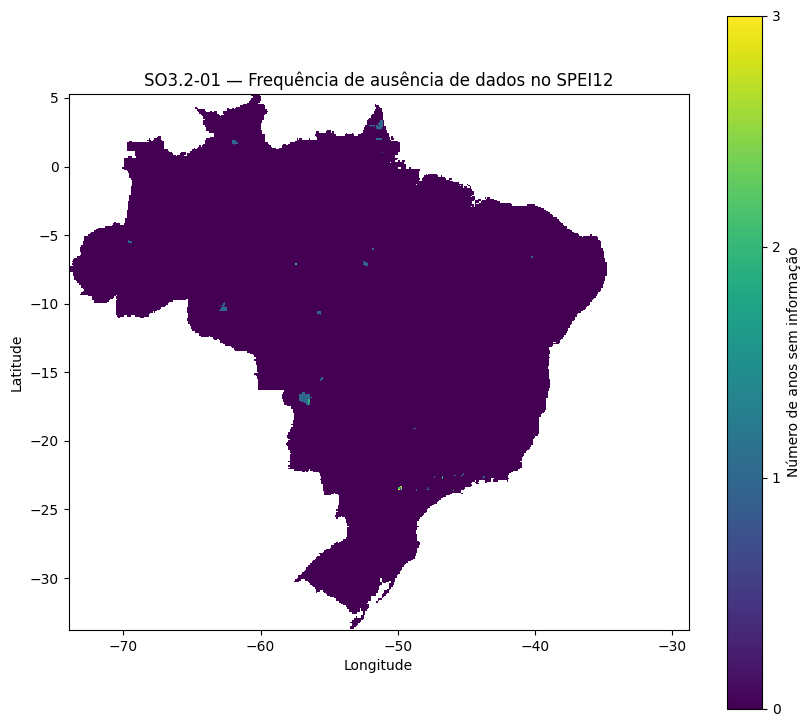

In [15]:
missing_year_count = len(years) - valid_year_count

plt.figure(figsize=(10, 9))

image = plt.imshow(
    np.where(
        ever_valid,
        missing_year_count,
        np.nan
    ),
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top,
    ],
    origin="upper",
    interpolation="nearest",
    vmin=0,
    vmax=int(missing_year_count[ever_valid].max()),
)

plt.colorbar(
    image,
    label="Número de anos sem informação",
    ticks=range(
        0,
        int(missing_year_count[ever_valid].max()) + 1
    ),
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "SO3.2-01 — Frequência de ausência de dados no SPEI12"
)

plt.show()

## 8. Testes automatizados de consistência

Os testes abaixo verificam os requisitos estruturais necessários para que os produtos possam prosseguir no fluxo do SO3.2.

A estabilidade completa da máscara **não** é tratada como requisito bloqueante neste notebook, pois a pequena variabilidade detectada constitui uma ressalva documental a ser investigada no SO3.1.

In [16]:
class_columns = [
    "class_1_pixels",
    "class_2_pixels",
    "class_3_pixels",
    "class_4_pixels",
    "class_5_pixels",
]

assert SPEI_DIR.is_dir(), \
    "Diretório dos GeoTIFFs SPEI12 não encontrado."

assert len(spei_files) == 24, \
    "Número inesperado de arquivos GeoTIFF."

assert len(invalid_names) == 0, \
    "Existem arquivos com nomenclatura incompatível."

assert missing_years == [], \
    "Existem anos ausentes na série."

assert unexpected_years == [], \
    "Existem anos inesperados na série."

assert duplicated_years == [], \
    "Existem anos duplicados."

assert raster_inventory["grid_matches_reference"].all(), \
    "As grades espaciais não são idênticas entre todos os anos."

assert raster_inventory["resolution_0_1deg"].all(), \
    "Há arquivos cuja resolução difere de 0.1°."

assert raster_inventory["classes_valid"].all(), \
    "Há valores fora das classes esperadas 1–5."

assert (raster_inventory["bands"] == 1).all(), \
    "Há GeoTIFFs com número inesperado de bandas."

assert raster_inventory["crs"].nunique() == 1, \
    "Há mais de um CRS na série."

assert raster_inventory["dtype"].nunique() == 1, \
    "Há mais de um tipo de dado na série."

assert raster_inventory["nodata"].nunique(dropna=False) == 1, \
    "Há mais de uma definição de NoData na série."

assert np.array_equal(
    raster_inventory[class_columns].sum(axis=1).to_numpy(),
    raster_inventory["valid_pixels"].to_numpy(),
), "A soma das classes não coincide com o número de pixels válidos."

print(
    "Controles estruturais obrigatórios atendidos. "
    "A variabilidade da máscara permanece registrada como ressalva."
)

Controles estruturais obrigatórios atendidos. A variabilidade da máscara permanece registrada como ressalva.


## 9. Registro dos produtos de QA/QC

Os produtos abaixo são gravados no diretório de logs do SO3.2.

- `so32_01_spei12_inventory.csv`: inventário técnico completo, incluindo SHA-256;
- `so32_01_spei12_class_counts.csv`: contagem anual das classes;
- `so32_01_spei12_mask_change_by_year.csv`: diferenças anuais em relação à máscara de 2000;
- `so32_01_spei12_variable_mask_pixels.csv`: pixels únicos com disponibilidade variável;
- `so32_01_spei12_missing_pixel_years.csv`: ocorrências célula × ano sem informação.

In [17]:
inventory_output = (
    SO32_LOGS
    / "so32_01_spei12_inventory.csv"
)

class_counts_output = (
    SO32_LOGS
    / "so32_01_spei12_class_counts.csv"
)

mask_change_output = (
    SO32_LOGS
    / "so32_01_spei12_mask_change_by_year.csv"
)

variable_output = (
    SO32_LOGS
    / "so32_01_spei12_variable_mask_pixels.csv"
)

missing_output = (
    SO32_LOGS
    / "so32_01_spei12_missing_pixel_years.csv"
)

raster_inventory.to_csv(
    inventory_output,
    index=False
)

class_counts.to_csv(
    class_counts_output,
    index=False
)

mask_change_by_year.to_csv(
    mask_change_output,
    index=False
)

variable_pixels.to_csv(
    variable_output,
    index=False
)

missing_by_year.to_csv(
    missing_output,
    index=False
)

print(f"Inventário técnico : {inventory_output}")
print(f"Classes anuais     : {class_counts_output}")
print(f"Máscaras anuais    : {mask_change_output}")
print(f"Pixels variáveis   : {variable_output}")
print(f"Ocorrências NoData : {missing_output}")

Inventário técnico : /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs/so32_01_spei12_inventory.csv
Classes anuais     : /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs/so32_01_spei12_class_counts.csv
Máscaras anuais    : /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs/so32_01_spei12_mask_change_by_year.csv
Pixels variáveis   : /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs/so32_01_spei12_variable_mask_pixels.csv
Ocorrências NoData : /content/drive/MyDrive/Cemaden/PRAIS4_SO3_BR/SO3.2/logs/so32_01_spei12_missing_pixel_years.csv


## 10. Síntese da validação

Os 24 produtos anuais provenientes do SO3.1 apresentam consistência quanto ao período, nomenclatura, sistema de referência espacial, resolução, dimensões, alinhamento da grade, número de bandas, tipo de dado e domínio das classes de seca.

Foi identificada pequena variabilidade temporal na máscara de dados. Dos **70.870 pixels** válidos em pelo menos um ano, **70.692 (99,75%)** apresentam informação em todos os 24 anos. Os **178 pixels** restantes apresentam ausência em um ou mais anos, totalizando **196 ocorrências pixel-ano sem informação**.

A comparação com a cobertura de 2000 mostra apenas perdas ocasionais em outros anos e nenhum ganho de pixels válidos fora dessa referência. A distribuição espacial das ausências demonstra, contudo, que elas não se restringem à borda da máscara territorial: apenas 6 dos 178 pixels estão a até 2 células da borda, 24 estão a até 5 células e 46 estão a até 10 células; a distância mediana é de aproximadamente 13,9 células.

Assim, a variabilidade observada **não pode ser atribuída exclusivamente ao recorte espacial do Brasil**. Sua origem deverá ser verificada no processamento do SO3.1. Entre as hipóteses técnicas a serem avaliadas está a implementação dos limiares empregados na classificação do SPEI-12, sem que essa hipótese seja considerada demonstrada neste notebook.

### Decisão operacional para o SO3.2

Nenhuma imputação, reclassificação ou alteração dos GeoTIFFs é realizada nesta etapa. Até que a origem das lacunas seja esclarecida, os valores ausentes permanecerão tratados como **NoData** e não serão interpretados como condição normal de seca.

### Situação da entrada

Os produtos são considerados **tecnicamente adequados para o prosseguimento do desenvolvimento do SO3.2, com ressalva documentada quanto à pequena variabilidade temporal da máscara espacial**.